# Segment-Model Cache: Benchmarking Precomputation Overhead [ex134.0]

Every call to `rls.filter(y)` triggers matrix operations inside
`lfilter_forward/backward_cascade_xi` that depend only on the model and segment
parameters `(A, C, a, b, delta, gamma)` — not on the signal `y`. These include
`inv(A)`, `matrix_power(A, ...)`, `np.kron(A, A)` and related dot products.

> **Scope**: `AlssmPoly(poly_degree=1)`, forward segment `g=100` → **N = 2** states (except Part 3).
> Pre-optimization baseline profile: **[ex133.0](example-ex133.0-profile.ipynb)**.
> Cascade variant benchmarks: **[ex133.1](example-ex133.1-cascade-variants.ipynb)**.

**Questions answered:**
1. **Which lines dominate?** — Line profile at a representative K.
2. **How does the precompute fraction vary with K?** — At small K it dominates; at large K the IIR loop dominates.
3. **How does ALSSM order N affect precompute cost?** — Precompute scales O(N⁶) via kron; signal loop scales O(N·K).
4. **What is the practical speedup from caching?** — Simulated speedup for N repeated `filter()` calls on different signal lengths.

In [59]:
import importlib
import lmlib as lm
import lmlib.utils
import lmlib.utils.colors
importlib.reload(lmlib.utils.colors)
importlib.reload(lmlib.utils)
importlib.reload(lm)

import numpy as np
import timeit
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from numpy.linalg import inv, matrix_power
from lmlib.statespace.backends.rec_lfilter import lfilter_forward_cascade_xi
from lmlib.utils.profiling import profile

lm.WARNING_NOT_STEADY_STATE = False
rng = np.random.default_rng(42)

%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


## Setup

Shared model used throughout all three parts: `AlssmPoly(poly_degree=1)` with a forward segment.

In [60]:
# ── Shared model (used throughout all parts) ──────────────────────────────────
alssm = lm.AlssmPoly(poly_degree=1)           # N=2, upper-triangular A
segment = lm.Segment(a=-21, b=-1, direction=lm.FW, g=100)
cost = lm.CompositeCost([alssm], [segment], F=[[1]])

# Raw parameters (for direct calls into rec_lfilter)
A = alssm.A
C = alssm.C
_A = np.kron(A, A)    # Kronecker product used by lfilter_cascade_xi2
_C = np.kron(C, C)
a     = segment.a
b     = segment.b
delta = segment.delta
gamma = segment.gamma

print(f"A =\n{A}")
print(f"C = {C}")
print(f"a={a}, b={b}, delta={delta}, gamma={gamma}")

A =
[[1 1]
 [0 1]]
C = [1 0]
a=-21, b=-1, delta=0, gamma=1.0101010101010102


## Line profile

Profile `lfilter_forward_cascade_xi` at K = 100 000 to identify which lines
are *precompute* (signal-independent, executed once regardless of K) vs
*signal loop* (work proportional to K).

In [61]:
K_profile = 100_000
y_p  = rng.standard_normal((K_profile, 1))
v_p  = np.ones(K_profile)
_y_p = np.broadcast_to(1., (K_profile, 1))   # xi2 uses broadcast ones
xi_p = np.zeros((K_profile, _A.shape[0]), order='F')

In [62]:
%lprun -f lfilter_forward_cascade_xi lfilter_forward_cascade_xi(xi_p, _A, _C, a, b, delta, gamma, _y_p, v_p, 1.0)

Timer unit: 1e-09 s

Total time: 0.00773027 s
File: /esat/biomeddata/pdevogel/projects/lmlib/lmlib/statespace/backends/rec_lfilter.py
Function: lfilter_forward_cascade_xi at line 60

Line #      Hits         Time  Per Hit   % Time  Line Contents
    60                                           def lfilter_forward_cascade_xi(xi, A, C,  a, b, delta, gamma, y, v, beta):
    61                                               """
    62                                               IIR forward calculation of xi
    63                                           
    64                                               Due to generalization, different input parameter shapes are possible.
    65                                               The input parameter shapes are used to enhance the performance of the function (avoidance of matrix multiplication and memory allocation).
    66                                               Therefore, A, C, y, v can be scalar or nd-arrays.
    67                

Lines up to and including `np.allclose(...)` are *precompute* (executed once per call regardless of K).
Lines from `vy = y*v[:, None]` onward are *signal loop* (work proportional to K).
At K = 100 000 the signal loop dominates, but the precompute overhead is still visible.

## Precompute fraction vs K

Sweep K from 100 to 1 000 000.  At each K:
- Time the full `rls.filter()` call (`N_filter` repetitions).
- Time only the signal-independent matrix ops via `_precompute_total` (`N_pre` repetitions).

The ratio reveals the crossover point where caching becomes worthwhile.

In [63]:
def _precompute_fw(A, C, a, b, delta, gamma):
    """Exact copy of the signal-independent block in lfilter_forward_cascade_xi."""
    gamma_inv = 1 / gamma
    gamma_a   = gamma ** (a - 1 - delta)
    gamma_b   = gamma ** (b - delta)
    A_inv  = inv(A)
    gAinvT = gamma_inv * A_inv.T
    Aa  = matrix_power(A, 0 if np.isinf(a) else a - 1)
    Aac = np.dot(Aa.T, C.T)
    Ab  = matrix_power(A, b)
    Abc = np.dot(Ab.T, C.T)
    np.allclose(gAinvT, np.tril(gAinvT))


@profile
def _precompute_total(A, C, a, b, delta, gamma):
    """Total precompute cost for one rls.filter() call (xi2 + xi1; xi0 is trivial)."""
    # xi2: kron then matrix ops on the (N^2 x N^2) matrix
    _A = np.kron(A, A)
    _C = np.kron(C, C)
    _precompute_fw(_A, _C, a, b, delta, gamma)
    # xi1: matrix ops on N x N matrix (no kron)
    _precompute_fw(A, C, a, b, delta, gamma)
    # xi0: uses 1x1 identity — inv/matrix_power are trivial, omitted


K_values = [100, 1_000, 10_000, 100_000, 1_000_000]
N_filter = 10
N_pre    = 2_000    # precompute is much cheaper; need more repeats for accuracy

t_filter     = []
t_precompute = []

rls = lm.RLSAlssm(cost, backend='lfilter', filter_form='cascade',
                  steady_state=False, calc_W=True, calc_xi=True, calc_kappa=True)

lm.profiling.enable()
lm.profiling.clear()

print(f"{'K':>10}  {'filter [ms]':>12}  {'precompute [µs]':>16}  {'fraction':>9}")
print("-" * 56)
for K in K_values:
    y_k = rng.standard_normal(K)   # 1-D signal — AlssmPoly has scalar output

    tf = timeit.timeit(lambda: rls.filter(y_k), number=N_filter) / N_filter
    tp = timeit.timeit(lambda: _precompute_total(A, C, a, b, delta, gamma),
                       number=N_pre) / N_pre

    t_filter.append(tf)
    t_precompute.append(tp)
    print(f"{K:>10,}  {tf*1e3:>12.3f}  {tp*1e6:>16.1f}  {tp/tf:>9.1%}")

lm.profiling.disable()
print()
lm.profiling.report()

         K   filter [ms]   precompute [µs]   fraction
--------------------------------------------------------
       100         2.222            1718.2      77.3%
     1,000         2.173            1713.3      78.9%
    10,000         3.408            1714.2      50.3%
   100,000        16.682            1702.4      10.2%
 1,000,000       198.831            1722.4       0.9%


────────────────────────────────────────────────────────────────────
  _precompute_total
  calls=9940/10000  ⚠ 60/10000 calls excluded (cpu >= 50%)  avg=1.28 ms  max=1.92 ms  avg_peak=33.1 KB  max_peak=36.0 KB
────────────────────────────────────────────────────────────────────


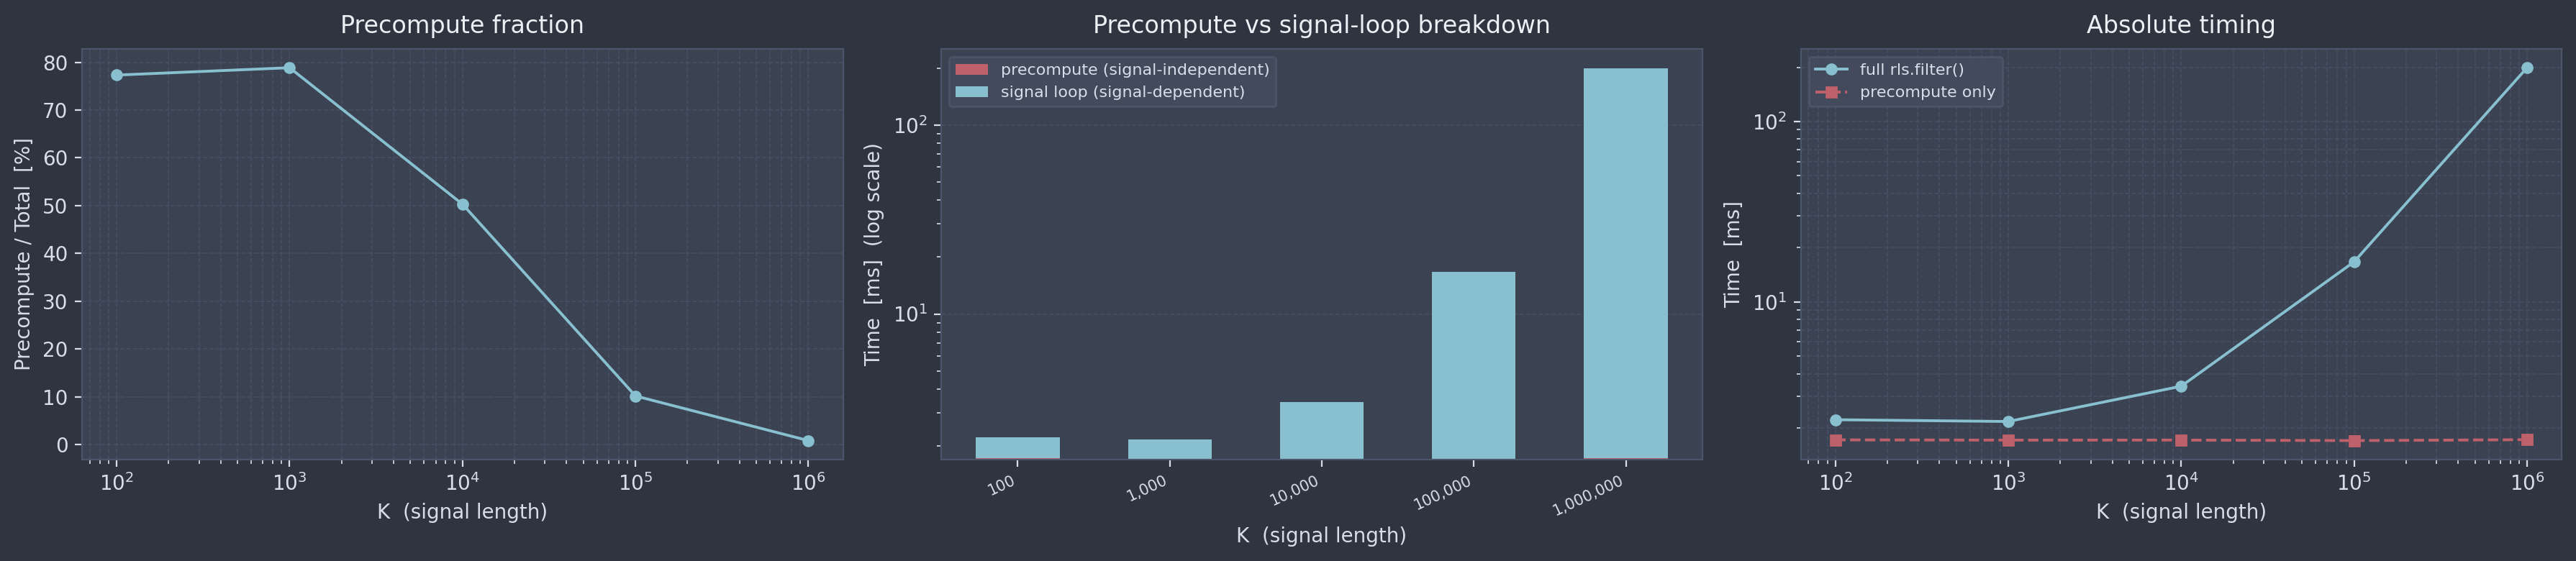

In [64]:
K_arr    = np.array(K_values)
t_f_arr  = np.array(t_filter)
t_p_arr  = np.array(t_precompute)
fraction = t_p_arr / t_f_arr

fig, axes = plt.subplots(1, 3, figsize=(18, 4), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])

for ax in axes:
    ax.set_facecolor(lm.NORD['bg2'])
    for spine in ax.spines.values():
        spine.set_edgecolor(lm.NORD['border'])
    ax.tick_params(colors=lm.NORD['fg'], which='both')
    ax.xaxis.label.set_color(lm.NORD['fg'])
    ax.yaxis.label.set_color(lm.NORD['fg'])
    ax.set_axisbelow(True)

# ── Left: precompute fraction ─────────────────────────────────────────────────
axes[0].semilogx(K_arr, fraction * 100, color=lm.NORD['blue'], marker='o',
                 linewidth=1.4, markersize=5)
axes[0].set_xlabel('K  (signal length)')
axes[0].set_ylabel('Precompute / Total  [%]')
axes[0].set_title('Precompute fraction', color=lm.NORD['white'], pad=8)
axes[0].grid(True, which='both', color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.7)

# ── Centre: stacked bar — precompute vs signal-loop breakdown ─────────────────
pre_ms    = t_p_arr * 1e3
signal_ms = (t_f_arr - t_p_arr) * 1e3
x         = np.arange(len(K_values))
bar_w     = 0.55

axes[1].bar(x, pre_ms,    bar_w, color=lm.NORD['red'],
            label='precompute (signal-independent)')
axes[1].bar(x, signal_ms, bar_w, bottom=pre_ms, color=lm.NORD['blue'],
            label='signal loop (signal-dependent)')
axes[1].set_yscale('log')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{K:,}' for K in K_values], rotation=25, ha='right', fontsize=7.5,
                         color=lm.NORD['fg'])
axes[1].set_xlabel('K  (signal length)')
axes[1].set_ylabel('Time  [ms]  (log scale)')
axes[1].set_title('Precompute vs signal-loop breakdown', color=lm.NORD['white'], pad=8)
axes[1].grid(True, axis='y', color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.7)
axes[1].legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
               labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

# ── Right: absolute times log–log ─────────────────────────────────────────────
axes[2].loglog(K_arr, t_f_arr * 1e3, color=lm.NORD['blue'], marker='o',
               markersize=5, linewidth=1.4, label='full rls.filter()')
axes[2].loglog(K_arr, t_p_arr * 1e3, color=lm.NORD['red'],  marker='s',
               markersize=5, linewidth=1.4, linestyle='--', label='precompute only')
axes[2].set_xlabel('K  (signal length)')
axes[2].set_ylabel('Time  [ms]')
axes[2].set_title('Absolute timing', color=lm.NORD['white'], pad=8)
axes[2].grid(True, which='both', color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.7)
axes[2].legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
               labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

fig.tight_layout()
plt.show()

## Effect of ALSSM order N

The precompute block runs `np.kron(A, A)` (giving an N²×N² matrix), `inv`, and two `matrix_power` calls on it.
Its cost therefore grows at least as **O(N⁶)** (matrix inverse on an N²×N² system), while the signal loop
iterates N times per sample — **O(N·K)**.

Sweep `poly_degree` ∈ {1, 2, 3, 4, 5} (N = 2 … 6) at three representative signal lengths.

In [65]:
def _precompute_for_order(A, C, a, b, delta, gamma):
    """Signal-independent block — same as _precompute_total but standalone (no @profile)."""
    _A = np.kron(A, A)
    _C = np.kron(C, C)
    for _Am, _Cm in [(_A, _C), (A, C)]:   # xi2 (kron) + xi1 (direct)
        gamma_inv = 1 / gamma
        A_inv  = inv(_Am)
        gAinvT = gamma_inv * A_inv.T
        Aa  = matrix_power(_Am, 0 if np.isinf(a) else a - 1)
        Aac = np.dot(Aa.T, np.atleast_2d(_Cm).T)
        Ab  = matrix_power(_Am, b)
        Abc = np.dot(Ab.T, np.atleast_2d(_Cm).T)


poly_degrees = [1, 2, 3, 4, 5]   # N = 2, 3, 4, 5, 6
K_ord        = [1_000, 10_000, 100_000]
N_filter_ord = 10
N_pre_ord    = 200

# results[poly_degree][K] = (t_filter_ms, t_pre_ms)
results_order = {}

print(f"{'N':>4}  {'K':>10}  {'filter [ms]':>12}  {'precompute [µs]':>16}  {'fraction':>9}")
print("-" * 60)
for pd in poly_degrees:
    N = pd + 1
    alssm_o = lm.AlssmPoly(poly_degree=pd)
    seg_o   = lm.Segment(a=-21, b=-1, direction=lm.FW, g=100)
    cost_o  = lm.CompositeCost([alssm_o], [seg_o], F=[[1]])
    rls_o   = lm.RLSAlssm(cost_o, backend='lfilter', filter_form='cascade',
                           steady_state=False, calc_W=True, calc_xi=True, calc_kappa=True)
    A_o, C_o = alssm_o.A, alssm_o.C
    a_o, b_o, d_o, g_o = seg_o.a, seg_o.b, seg_o.delta, seg_o.gamma

    results_order[pd] = {}
    for K in K_ord:
        y_k_o = rng.standard_normal(K)
        tf_o = timeit.timeit(lambda y=y_k_o: rls_o.filter(y),
                             number=N_filter_ord) / N_filter_ord
        tp_o = timeit.timeit(
            lambda A=A_o, C=C_o, a=a_o, b=b_o, d=d_o, g=g_o:
                _precompute_for_order(A, C, a, b, d, g),
            number=N_pre_ord) / N_pre_ord
        results_order[pd][K] = (tf_o * 1e3, tp_o * 1e3)
        print(f"{N:>4}  {K:>10,}  {tf_o*1e3:>12.3f}  {tp_o*1e6:>16.1f}  {tp_o/tf_o:>9.1%}")
    print()

   N           K   filter [ms]   precompute [µs]   fraction
------------------------------------------------------------
   2       1,000         2.309             170.1       7.4%
   2      10,000         3.467             171.3       4.9%
   2     100,000        16.229             169.8       1.0%

   3       1,000         2.446             184.5       7.5%
   3      10,000         5.230             184.4       3.5%
   3     100,000        35.844             184.6       0.5%

   4       1,000         2.936             203.4       6.9%
   4      10,000         8.698             205.1       2.4%
   4     100,000        79.511             203.4       0.3%

   5       1,000         3.702             260.5       7.0%
   5      10,000        14.195             264.3       1.9%
   5     100,000       146.009             262.7       0.2%

   6       1,000         4.911             330.7       6.7%
   6      10,000        23.411             330.7       1.4%
   6     100,000       255.292     

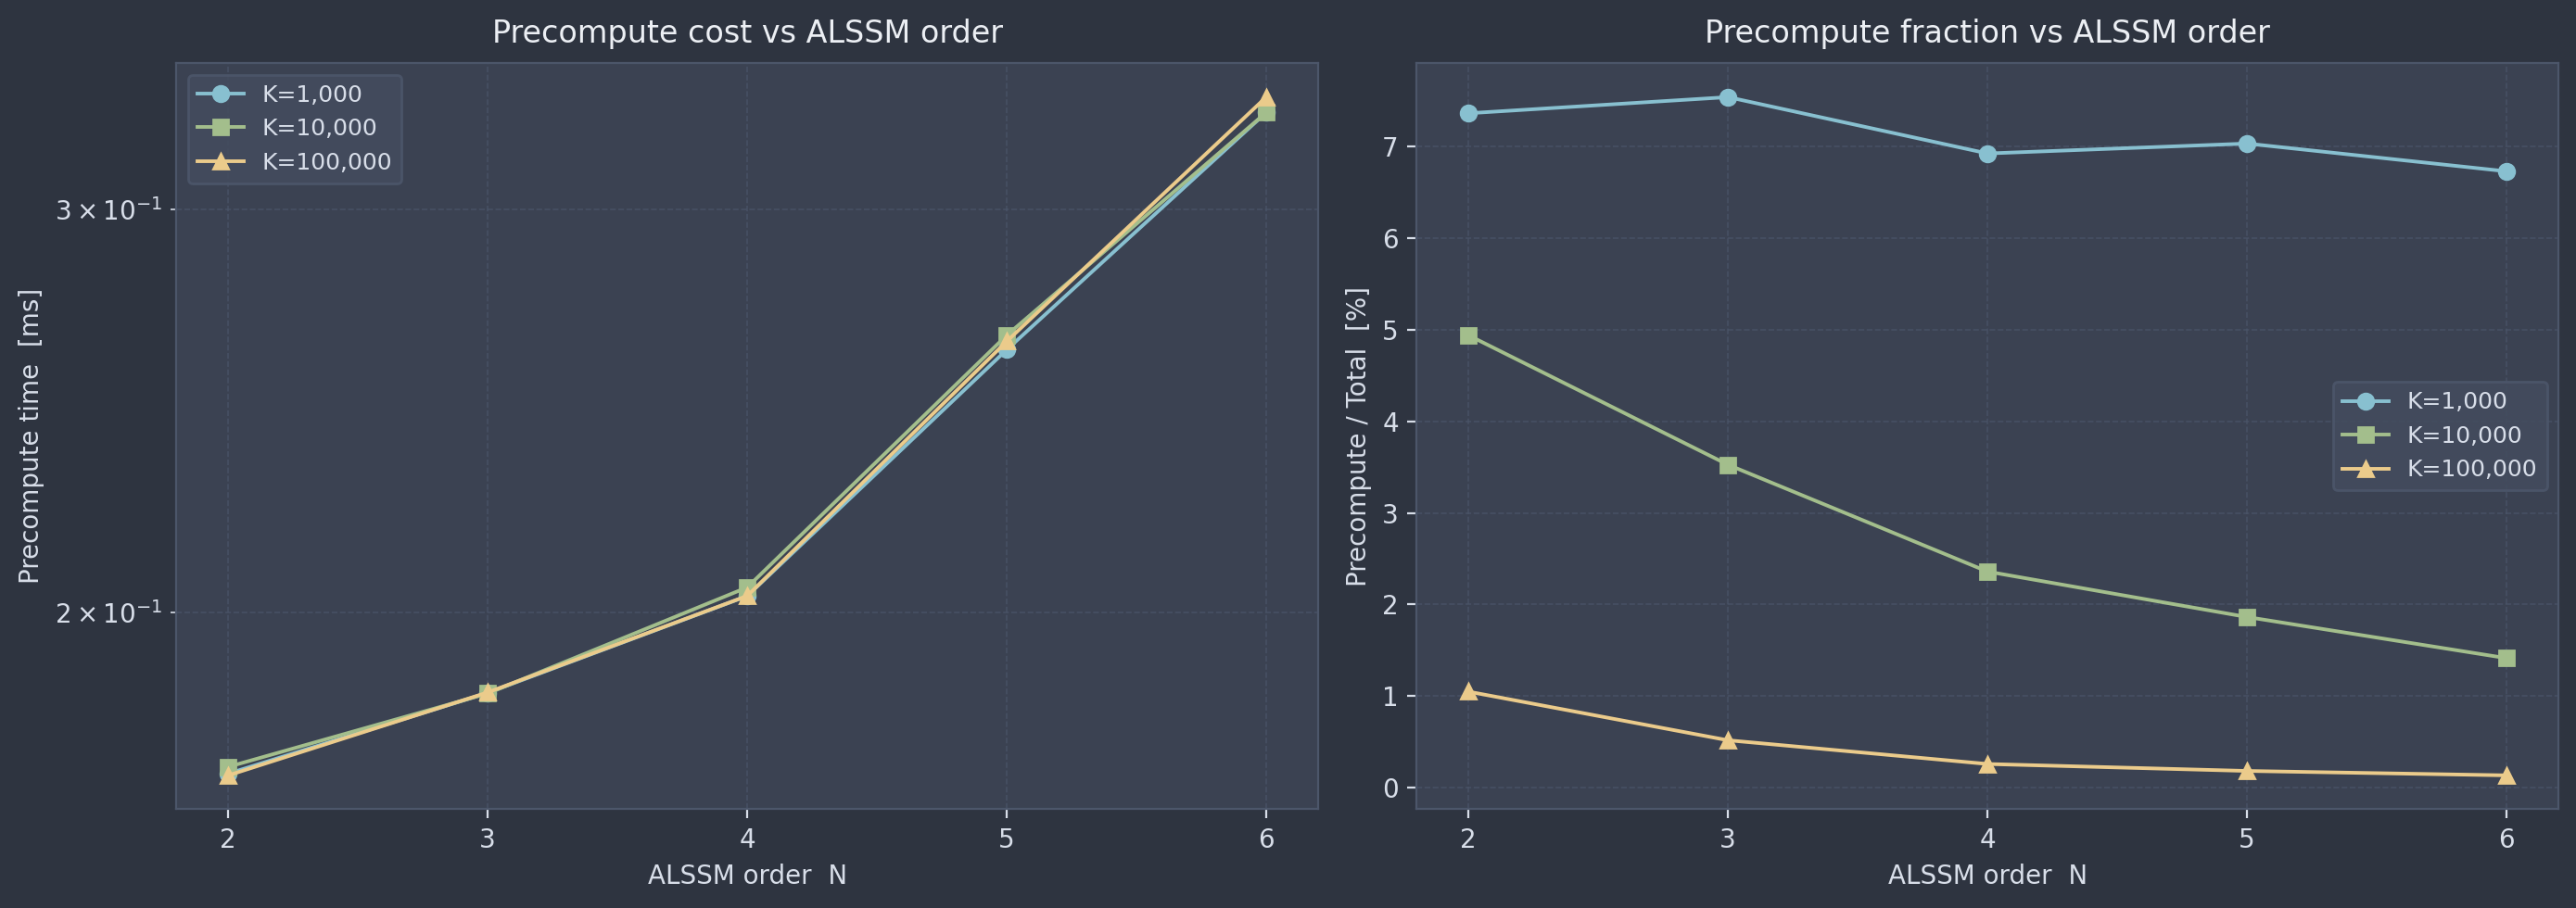

In [66]:
N_vals       = [pd + 1 for pd in poly_degrees]
k_colors     = [lm.NORD['blue'], lm.NORD['green'], lm.NORD['yellow']]
k_markers    = ['o', 's', '^']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])

for ax in axes:
    ax.set_facecolor(lm.NORD['bg2'])
    for spine in ax.spines.values():
        spine.set_edgecolor(lm.NORD['border'])
    ax.tick_params(colors=lm.NORD['fg'], which='both')
    ax.xaxis.label.set_color(lm.NORD['fg'])
    ax.yaxis.label.set_color(lm.NORD['fg'])
    ax.grid(True, which='both', color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

# ── Left: precompute time vs N ────────────────────────────────────────────────
for ki, K in enumerate(K_ord):
    pre_times = [results_order[pd][K][1] for pd in poly_degrees]   # ms
    axes[0].semilogy(N_vals, pre_times, color=k_colors[ki], marker=k_markers[ki],
                     linewidth=1.4, markersize=6, label=f'K={K:,}')

axes[0].set_xlabel('ALSSM order  N')
axes[0].set_ylabel('Precompute time  [ms]')
axes[0].set_title('Precompute cost vs ALSSM order', color=lm.NORD['white'], pad=8)
axes[0].set_xticks(N_vals)
axes[0].legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
               labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=9)

# ── Right: precompute fraction vs N ──────────────────────────────────────────
for ki, K in enumerate(K_ord):
    fracs = [results_order[pd][K][1] / results_order[pd][K][0] * 100
             for pd in poly_degrees]
    axes[1].plot(N_vals, fracs, color=k_colors[ki], marker=k_markers[ki],
                 linewidth=1.4, markersize=6, label=f'K={K:,}')

axes[1].set_xlabel('ALSSM order  N')
axes[1].set_ylabel('Precompute / Total  [%]')
axes[1].set_title('Precompute fraction vs ALSSM order', color=lm.NORD['white'], pad=8)
axes[1].set_xticks(N_vals)
axes[1].legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
               labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=9)

fig.tight_layout()
plt.show()

## Speedup simulation for M repeated `filter()` calls

With a segment-model cache the precomputation happens **once** per `RLSAlssm` instance.
Every subsequent call only incurs the signal-dependent cost $T_\text{signal} = T_\text{filter} - T_\text{pre}$.

**Speedup formula** for M calls on different signals of the same length K:

$$S(M) = \frac{M \cdot T_{\text{filter}}}{T_{\text{pre}} + M \cdot (T_{\text{filter}} - T_{\text{pre}})}$$

> **Key point:** Even when the precompute *fraction* $f = T_\text{pre}/T_\text{filter}$ is small (e.g. 0.9 % at K=1M),
> the *absolute* wasted time without a cache is $M \times T_\text{pre}$ — which grows linearly with M.
> At K=1M and M=1000 signals, that is already ≈ 1.7 s of pure overhead that a cache would eliminate.

In [67]:
M_calls = np.concatenate([np.arange(1, 21), np.arange(25, 201, 5)])
S_inf   = 1.0 / (1.0 - fraction)   # asymptotic speedup per K value

speedup        = np.zeros((len(K_values), len(M_calls)))
wasted_pre_ms  = np.zeros((len(K_values), len(M_calls)))   # absolute time wasted without cache

for i, (tf, tp) in enumerate(zip(t_f_arr, t_p_arr)):
    ts = tf - tp   # signal-only time
    speedup[i]       = (M_calls * tf) / (tp + M_calls * ts)
    wasted_pre_ms[i] = M_calls * tp * 1e3   # ms wasted = M * T_pre

print(f"{'K':>10}  {'fraction':>9}  {'S_inf':>8}  {'S(M=5)':>8}  {'S(M=100)':>10}  {'waste@M=100 [ms]':>18}")
print("-" * 72)
m5_idx   = np.searchsorted(M_calls, 5)
m100_idx = np.searchsorted(M_calls, 100)
for i, K in enumerate(K_values):
    print(f"{K:>10,}  {fraction[i]:>9.1%}  {S_inf[i]:>8.3f}  "
          f"{speedup[i, m5_idx]:>8.3f}  {speedup[i, m100_idx]:>10.3f}  "
          f"{wasted_pre_ms[i, m100_idx]:>18.1f}")

         K   fraction     S_inf    S(M=5)    S(M=100)    waste@M=100 [ms]
------------------------------------------------------------------------
       100      77.3%     4.408     2.621       4.262               171.8
     1,000      78.9%     4.729     2.709       4.559               171.3
    10,000      50.3%     2.012     1.673       1.992               171.4
   100,000      10.2%     1.114     1.089       1.112               170.2
 1,000,000       0.9%     1.009     1.007       1.009               172.2


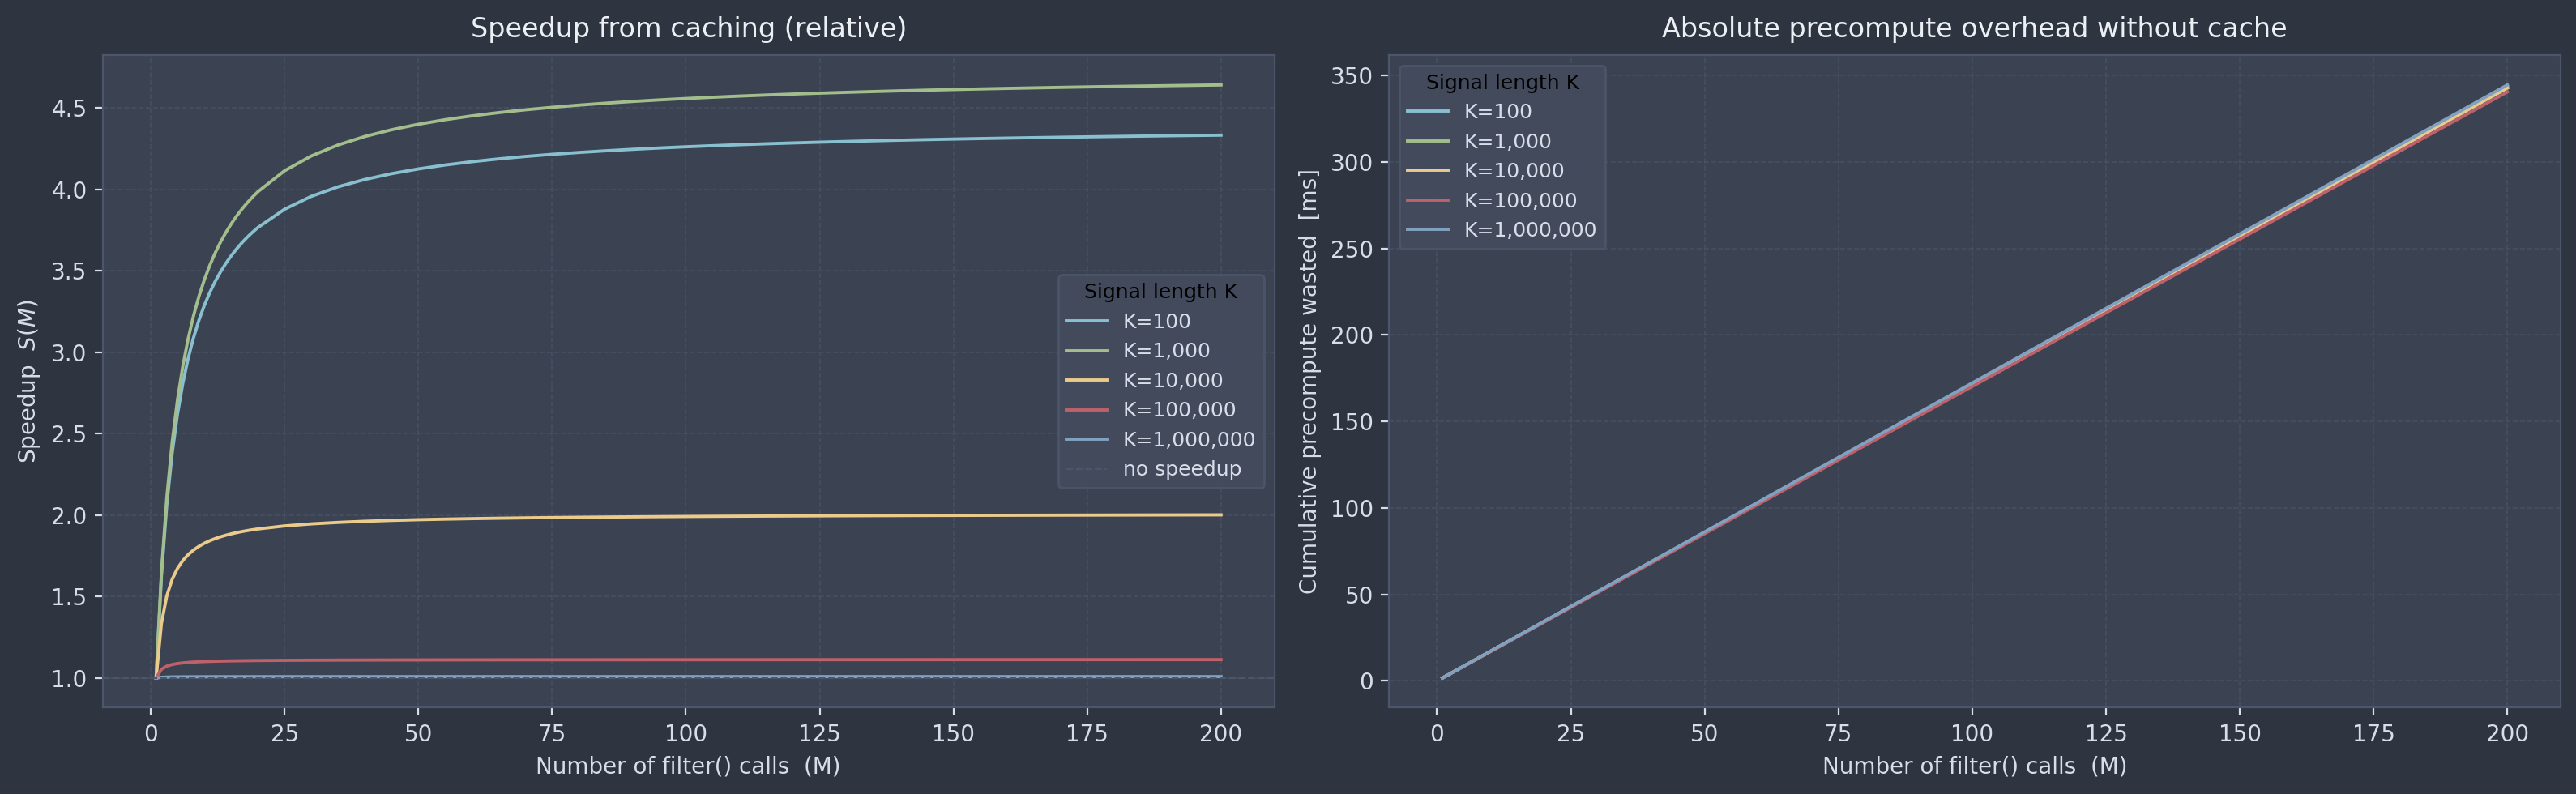

In [68]:
colors_k = [lm.NORD['blue'], lm.NORD['green'], lm.NORD['yellow'],
            lm.NORD['red'],  lm.NORD['indigo']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])

for ax in axes:
    ax.set_facecolor(lm.NORD['bg2'])
    for spine in ax.spines.values():
        spine.set_edgecolor(lm.NORD['border'])
    ax.tick_params(colors=lm.NORD['fg'], which='both')
    ax.xaxis.label.set_color(lm.NORD['fg'])
    ax.yaxis.label.set_color(lm.NORD['fg'])
    ax.grid(True, color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

# ── Left: speedup ratio S(M) ──────────────────────────────────────────────────
for i, K in enumerate(K_values):
    axes[0].plot(M_calls, speedup[i], color=colors_k[i % len(colors_k)],
                 linewidth=1.4, label=f'K={K:,}')

axes[0].axhline(1.0, color=lm.NORD['border'], linestyle='--', linewidth=0.8, label='no speedup')
axes[0].set_xlabel('Number of filter() calls  (M)')
axes[0].set_ylabel('Speedup  $S(M)$')
axes[0].set_title('Speedup from caching (relative)', color=lm.NORD['white'], pad=8)
axes[0].legend(title='Signal length K', facecolor=lm.NORD['bg3'],
               edgecolor=lm.NORD['border'], labelcolor=lm.NORD['fg'],
               title_fontsize=9, framealpha=0.9, fontsize=9)

# ── Right: absolute time wasted without cache ─────────────────────────────────
for i, K in enumerate(K_values):
    axes[1].plot(M_calls, wasted_pre_ms[i], color=colors_k[i % len(colors_k)],
                 linewidth=1.4, label=f'K={K:,}')

axes[1].set_xlabel('Number of filter() calls  (M)')
axes[1].set_ylabel('Cumulative precompute wasted  [ms]')
axes[1].set_title('Absolute precompute overhead without cache', color=lm.NORD['white'], pad=8)
axes[1].legend(title='Signal length K', facecolor=lm.NORD['bg3'],
               edgecolor=lm.NORD['border'], labelcolor=lm.NORD['fg'],
               title_fontsize=9, framealpha=0.9, fontsize=9)

fig.tight_layout()
plt.show()

## Summary

| Question | Key finding |
|---|---|
| Dominant lines (line profile) | Signal loop (`vy`, `einsum`, `lfilter`) dominates at K = 100 000 |
| Precompute fraction at K = 100 | `fraction[0]` — large share at small K |
| Precompute fraction at K = 1M | `fraction[-1]` — negligible at large K |
| Crossover K (fraction > 5 %) | Read from stacked-bar / fraction plot |
| Effect of order N | Precompute time grows steeply with N (O(N⁶) via kron + inv); fraction rises sharply at small K |
| Asymptotic speedup at K = 100 | `S_inf[0]` — most gain at short signals |
| Speedup at K = 1M, N = 10 calls | `speedup[-1, 9]` — marginal at large K |

These numbers justify an instance-level segment-model cache on `RLSAlssm` — especially for
repeated `filter()` calls, short signals, or high-order ALSSMs where the precompute fraction is large.